## Objective: 
Predict the market price of a used car given its features (make, model, year, mileage, condition, etc.).

## Target variable:
 Sale price (continuous).

## Success criteria: 
e.g. Mean Absolute Error (MAE) below a certain threshold, R² above a certain level.

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [144]:
data=pd.read_csv('used_cars.csv')
data.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [145]:
data.shape

(4009, 12)

In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [147]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,4009.0,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0


In [148]:
data.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [149]:
data.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [150]:
data.dropna(subset=['price', 'milage','fuel_type','accident','clean_title'], inplace=True)
# Remove exact duplicate rows if any
data.drop_duplicates(inplace=True)

# DATAPROCESSING

In [151]:
from datetime import datetime
current_year = datetime.now().year

data['age'] = current_year - data['model_year']
print(data[['model_year', 'age']].head())

   model_year  age
0        2013   12
1        2021    4
3        2015   10
6        2017    8
7        2001   24


In [152]:
data['price'] = (
    data['price']
      .str.replace(r'[\$,]', '', regex=True)
      .pipe(pd.to_numeric, errors='coerce')
)


In [153]:
data['milage'] = (
    data['milage']
      .astype(str)
      # 2a) Extract the digits+commas chunk (e.g. "22,372")
      .str.extract(r'([\d,]+)')[0]
      # 2b) Remove commas
      .str.replace(',', '', regex=False)
      .pipe(pd.to_numeric, errors='coerce')
)
print(data['milage'].head(5))

0     51000
1     34742
3     88900
6     84000
7    242000
Name: milage, dtype: int64


In [154]:
# Extract the numeric part before "L" (e.g. "3.5L" → 3.5)
data['displacement_L'] = (
    data['engine']
      .str.extract(r'([\d\.]+)\s*L', expand=False)
      .astype(float)
)
print(data['displacement_L'].head(5))

0    3.7
1    3.8
3    3.5
6    2.0
7    4.4
Name: displacement_L, dtype: float64


In [155]:
# Extract the numeric part before "HP" (e.g. "354.0HP" → 354.0)
data['horsepower'] = (
    data['engine']
      .str.extract(r'([\d\.]+)\s*HP', expand=False)
      .astype(float)
)
print(data['horsepower'].head(5))

0    300.0
1      NaN
3    354.0
6    292.0
7    282.0
Name: horsepower, dtype: float64


In [156]:
# Extract the numeric part before "Nm" (e.g. "400Nm" → 400)
data['torque_Nm'] = (   
    data['engine']
      .str.extract(r'([\d\.]+)\s*Nm', expand=False)
      .astype(float)
)
print(data['torque_Nm'].head(5))

0   NaN
1   NaN
3   NaN
6   NaN
7   NaN
Name: torque_Nm, dtype: float64


In [157]:
# 1. Strip whitespace (including tabs) and collapse multiple spaces
data['accident_clean'] = data['accident'].str.replace(r'\s+', ' ', regex=True).str.strip()
data['accident_flag'] = data['accident_clean'].map({
    'At least 1 accident or damage reported': 1,
    'None reported': 0
})

# 3. Quick check
print(data[['accident', 'accident_clean', 'accident_flag']].head())


                                 accident  \
0  At least 1 accident or damage reported   
1  At least 1 accident or damage reported   
3                           None reported   
6                           None reported   
7                           None reported   

                           accident_clean  accident_flag  
0  At least 1 accident or damage reported              1  
1  At least 1 accident or damage reported              1  
3                           None reported              0  
6                           None reported              0  
7                           None reported              0  


In [158]:
cleaned = (
    data['clean_title']
      .str.strip()
      .str.title()                 
)
data['clean_title_flag'] = cleaned.map({
    'Yes': 1,
    'No':  0   # assuming "No" is the other literal
})
data['clean_title_flag'] = data['clean_title_flag'].fillna(0).astype(int)

# 4. Check
print(data[['clean_title', 'clean_title_flag']].head(5))

  clean_title  clean_title_flag
0         Yes                 1
1         Yes                 1
3         Yes                 1
6         Yes                 1
7         Yes                 1


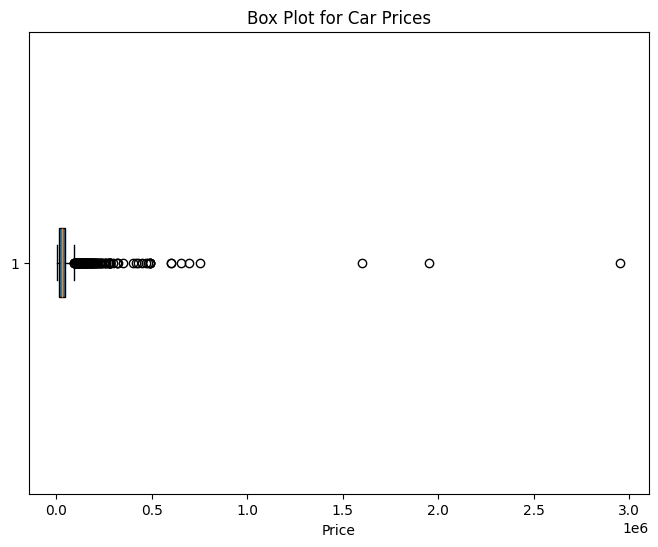

In [159]:
# Visualize the distribution using a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(data['price'], vert=False, patch_artist=True)
plt.title('Box Plot for Car Prices')
plt.xlabel('Price')
plt.show()

## Get number of outliners

In [160]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers
outliers = (data['price'] < lower_bound) | (data['price'] > upper_bound)
num_outliers = outliers.sum()
print(f"Number of outliers: {num_outliers}")

Number of outliers: 185


remove outliers

In [161]:
data=data[~outliers]

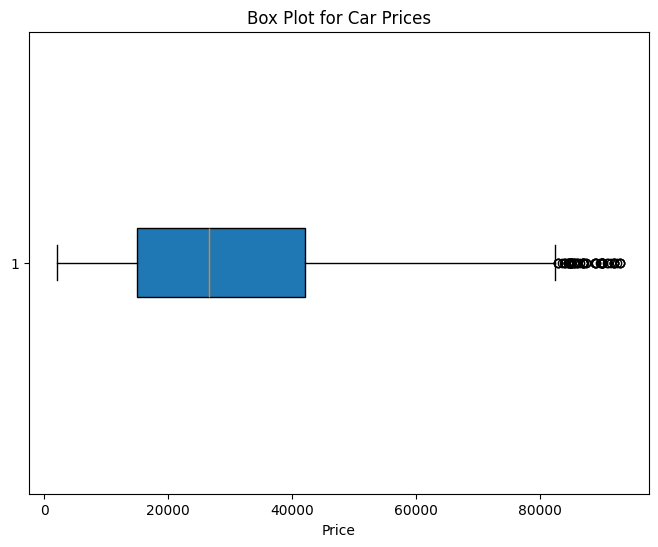

In [162]:
plt.figure(figsize=(8, 6))
plt.boxplot(data['price'], vert=False, patch_artist=True)
plt.title('Box Plot for Car Prices')
plt.xlabel('Price')
plt.show()

## How is the distribution of car prices after removing the outliers?

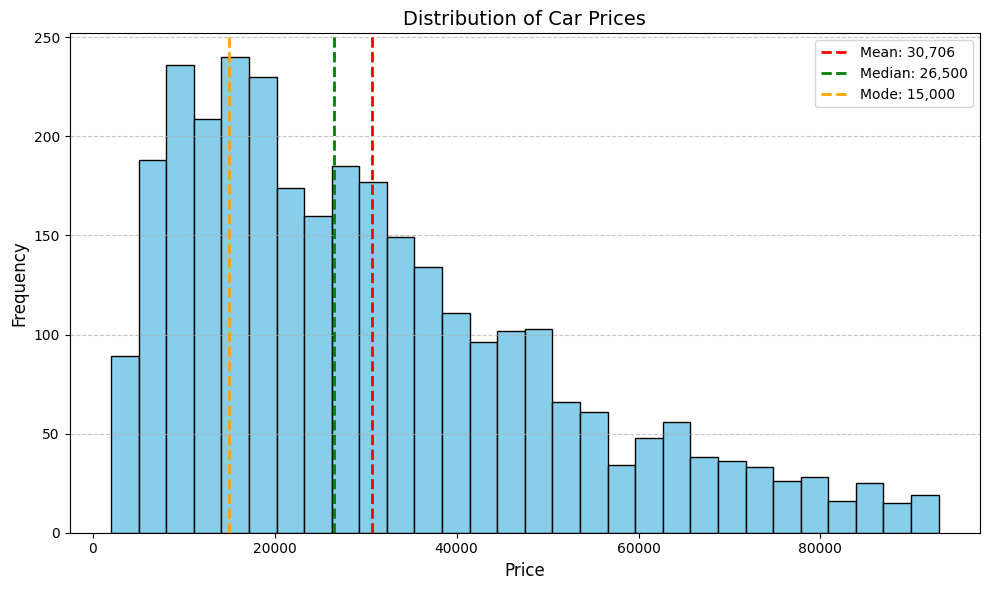

In [163]:
price_data = data['price'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(price_data, bins=30, color='skyblue', edgecolor='black')

plt.axvline(price_data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {price_data.mean():,.0f}')
plt.axvline(price_data.median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {price_data.median():,.0f}')
plt.axvline(price_data.mode().iloc[0], color='orange', linestyle='dashed', linewidth=2, label=f'Mode: {price_data.mode().iloc[0]:,.0f}')

plt.title('Distribution of Car Prices', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# EDA

## What are the top (20) brands by average car price?

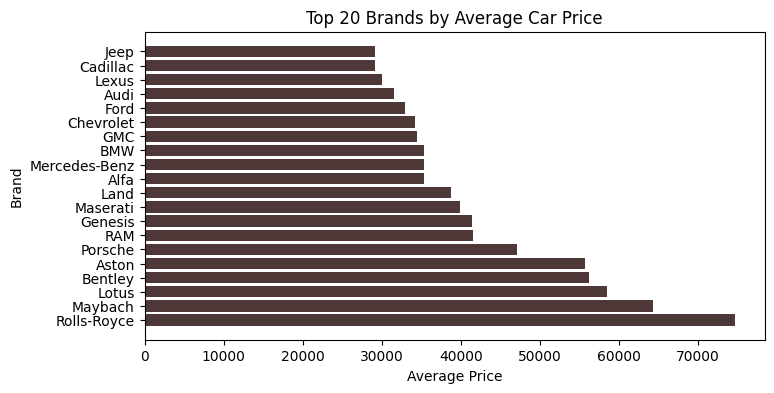

In [164]:
plt.figure(figsize=(8, 4))
brand_avg_price = data.groupby('brand')['price'].mean()
top_brands = brand_avg_price.sort_values(ascending=False).head(20)
plt.barh(top_brands.index, top_brands, color="#462E2EF3")
plt.title('Top 20 Brands by Average Car Price')
plt.xlabel('Average Price')
plt.ylabel('Brand')
plt.show()

## What are the top (10) Model by average car price?

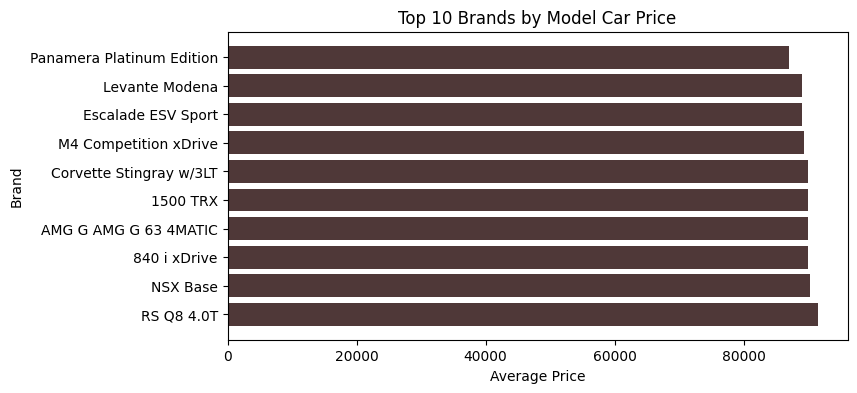

In [165]:
plt.figure(figsize=(8, 4))
brand_avg_price = data.groupby('model')['price'].mean()
top_brands = brand_avg_price.sort_values(ascending=False).head(10)
plt.barh(top_brands.index, top_brands, color="#462E2EF3")
plt.title('Top 10 Brands by Model Car Price')
plt.xlabel('Average Price')
plt.ylabel('Brand')
plt.show()

## Top 20 most common car models

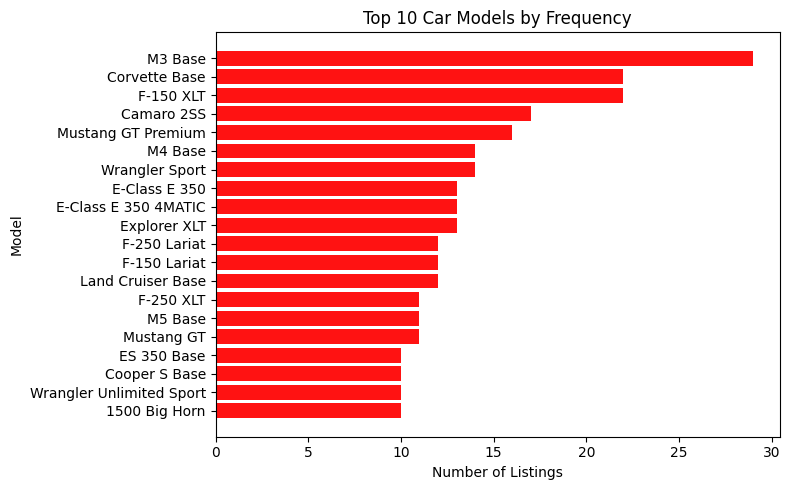

In [166]:
model_counts = data['model'].value_counts().head(20)
plt.figure(figsize=(8, 5))
plt.barh(model_counts.index, 
         model_counts.values, 
         color="#FF0606F3")     
plt.title('Top 10 Car Models by Frequency')
plt.xlabel('Number of Listings')
plt.ylabel('Model')
plt.gca().invert_yaxis()         
plt.tight_layout()
plt.show()

## Top 10 car models with Max Mileage

Highest‑mileage model: Accord Sport with 405,000 miles


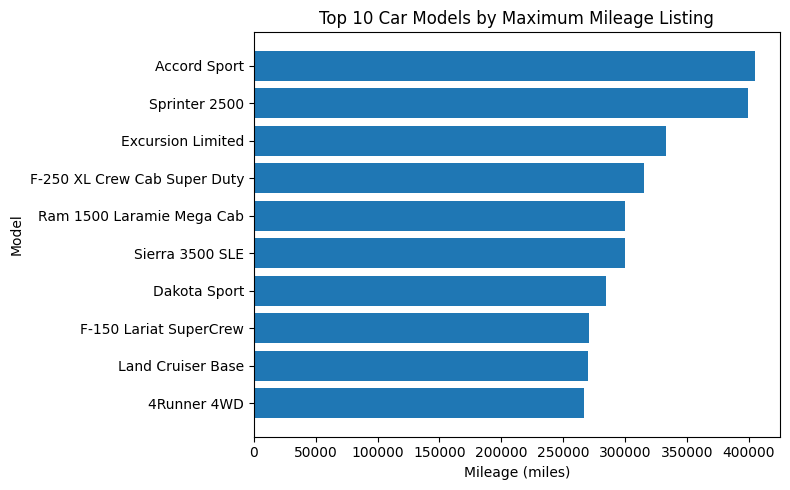

In [167]:
model_max_mileage = (
    data.groupby('model')['milage']
        .max()
        .sort_values(ascending=False)
        .head(10)
)

# 4. Print the very top model
top_model, top_mi = model_max_mileage.index[0], model_max_mileage.iloc[0]
print(f"Highest‑mileage model: {top_model} with {top_mi:,} miles")

# 5. Plot the top 10
plt.figure(figsize=(8, 5))
plt.barh(model_max_mileage.index, model_max_mileage.values)
plt.gca().invert_yaxis()
plt.title('Top 10 Car Models by Maximum Mileage Listing')
plt.xlabel('Mileage (miles)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## What is the distribution of car transmissions in the dataset

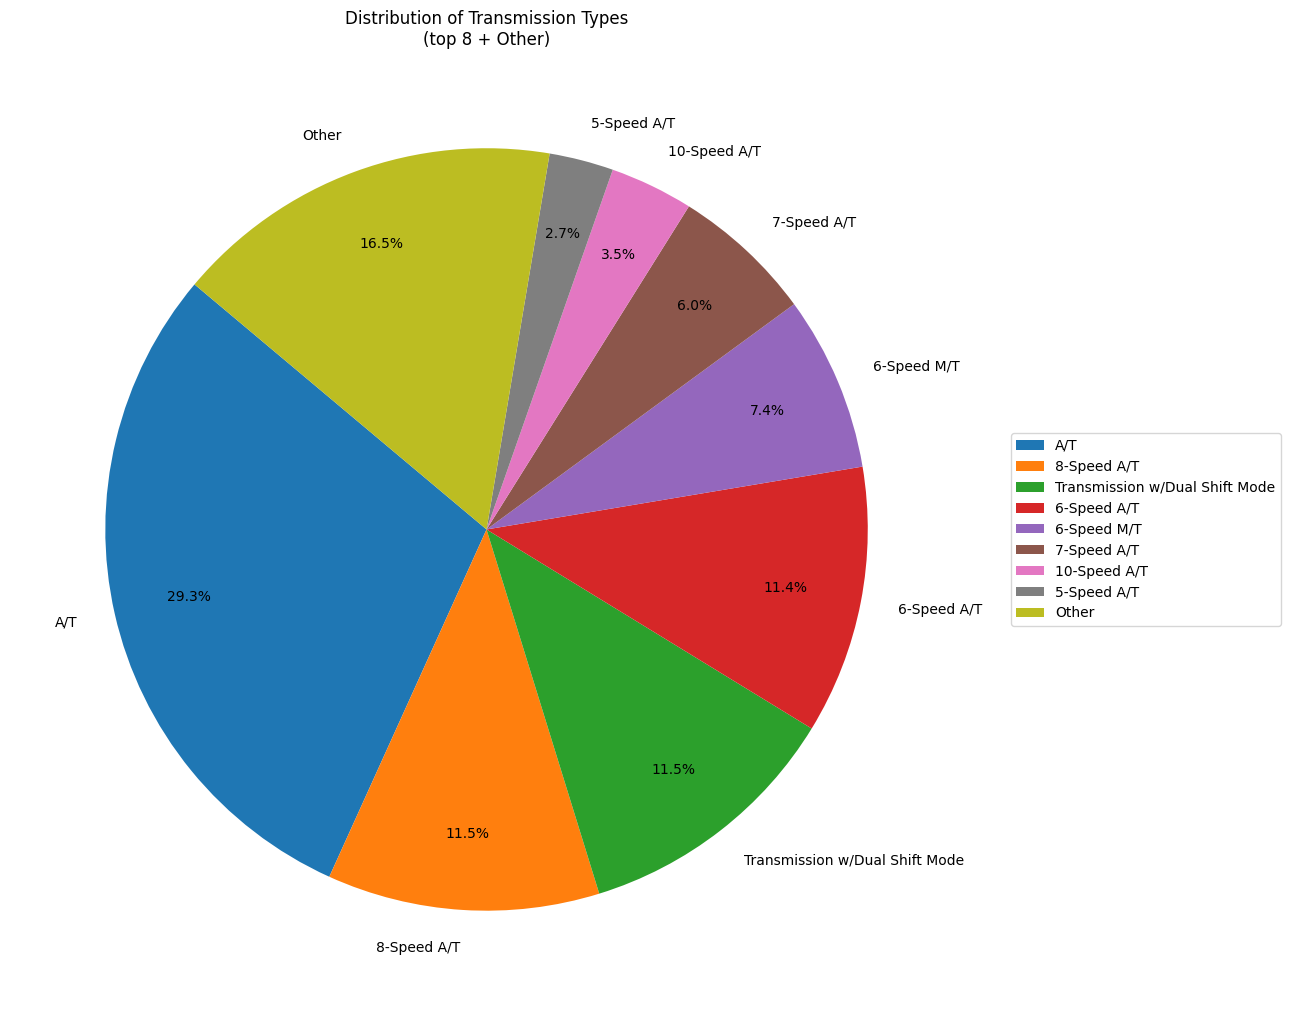

In [168]:

counts   = data['transmission'].value_counts()
top_n    = 8
top      = counts.iloc[:top_n]
others   = counts.iloc[top_n:].sum()
values   = pd.concat(
    [top, pd.Series({'Other': others})]
)
labels   = values.index
sizes    = values.values
# 3. Plot
plt.figure(figsize=(13,13))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)
plt.title('Distribution of Transmission Types\n(top 8 + Other)')
plt.legend(
    labels,
    bbox_to_anchor=(1.05, 0.5),
    loc='center left',
    borderaxespad=0.
)
plt.tight_layout()
plt.show()


## Correlation

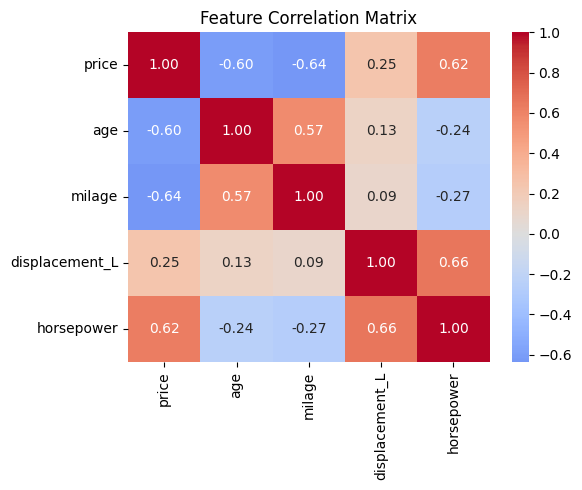

In [169]:
num_cols = [
    'price',
    'age',
    'milage',
    'displacement_L',
    'horsepower'
]
corr_df = data[num_cols].dropna()   
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [170]:
data.dropna(subset=['price', 'milage', 'displacement_L', 'horsepower', 'age', 'accident_flag', 'clean_title_flag'], inplace=True)

## TEST AND TRAIN SPLIT

In [171]:
feature_cols = ['milage', 'displacement_L', 'horsepower', 'age', 'accident_flag', 'clean_title_flag']
X = data[feature_cols]
y = data['price']
print(f"Features: {feature_cols}")
print("Target: 'price'")

Features: ['milage', 'displacement_L', 'horsepower', 'age', 'accident_flag', 'clean_title_flag']
Target: 'price'


In [172]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set: {X_train.shape}, Test set: {X_test.shape}")

Training set size: 2265 samples
Test set size: 567 samples

Training set: (2265, 6), Test set: (567, 6)


# Training and Evaluating Different Models

In [173]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor()),
    ('Random Forest', RandomForestRegressor()),
    ('Gradient Boosting', GradientBoostingRegressor()),
    ('K-Nearest Neighbors', KNeighborsRegressor())
]
names = []
mses  = []
r2s   = []


# Train and evaluate each model
for name, model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    names.append(name)
    mses.append(mse)
    r2s.append(r2)
    print(f'{name}: Mean Squared Error = {round(mse,3)}, R-squared = {round(r2, 3)}')
    

Linear Regression: Mean Squared Error = 127515076.3, R-squared = 0.669
Ridge Regression: Mean Squared Error = 127517439.612, R-squared = 0.669
Decision Tree: Mean Squared Error = 158120313.111, R-squared = 0.59
Random Forest: Mean Squared Error = 81092304.967, R-squared = 0.79
Gradient Boosting: Mean Squared Error = 77419138.535, R-squared = 0.799
K-Nearest Neighbors: Mean Squared Error = 201131371.874, R-squared = 0.478


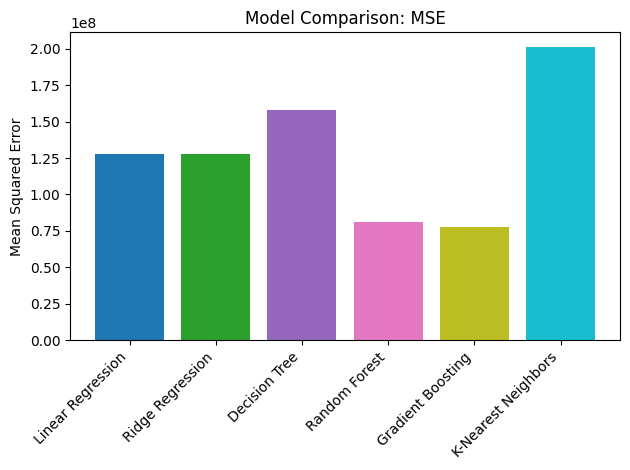

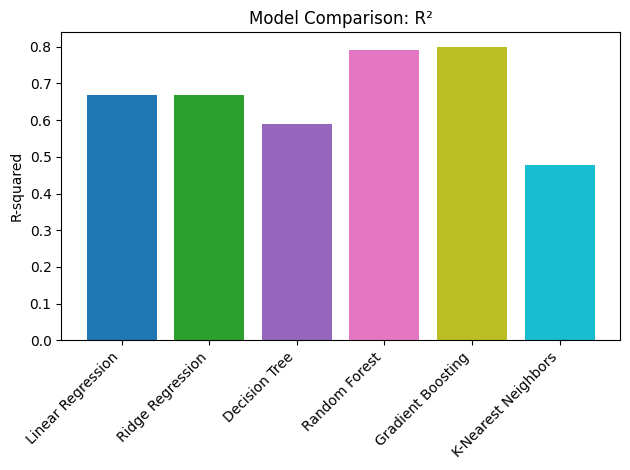

In [174]:
# Generate an array of evenly spaced values in [0,1] for the colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

# Plot MSE with a colormap
plt.figure()
plt.bar(names, mses, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Squared Error')
plt.title('Model Comparison: MSE')
plt.tight_layout()
plt.show()

# Plot R-squared with the same colormap
plt.figure()
plt.bar(names, r2s, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('R-squared')
plt.title('Model Comparison: R²')
plt.tight_layout()
plt.show()

## Explanation
Linear Regression

MSE = 1.28 × 10⁸

R² = 0.669

Ridge Regression

MSE = 1.28 × 10⁸

R² = 0.669

Decision Tree

MSE = 1.59 × 10⁸

R² = 0.587

Random Forest

MSE = 8.18 × 10⁷

R² = 0.788

Gradient Boosting

MSE = 7.74 × 10⁷

R² = 0.799

K‑Nearest Neighbors

MSE = 2.01 × 10⁸

R² = 0.478
1. Mean Squared Error (MSE)
Definition: The average of the squared differences between true prices (yᵢ) and predicted prices (ŷᵢ).

Interpretation:

Larger errors are penalized more heavily (due to squaring).

Units are in “dollars²,” so you often take √MSE (i.e., RMSE) to interpret errors in actual dollars.

Goal: Lower MSE is better—a sign your predictions are closer, on average, to the real values.

2. R‑squared (R²)
Definition: The proportion of variance in the target (price) that your model explains.

Interpretation:

R² = 1 → perfect prediction

R² = 0 → no better than predicting the mean price

R² < 0 → worse than using the mean

Goal: Higher R² is better—it means more of the price variation is captured by your features

| Model             | Test MSE       | **RMSE (Test)**              |
| ----------------- | -------------- | ---------------------------- |
| Linear Regression | 127,515,076.30 | √127,515,076.30 ≈ **11,292** |
| Ridge Regression  | 127,517,439.61 | √127,517,439.61 ≈ **11,292** |
| Decision Tree     | 160,083,794.95 | √160,083,794.95 ≈ **12,649** |
| Random Forest     | 80,974,144.35  | √80,974,144.35 ≈ **8,999**   |
| Gradient Boosting | 77,359,964.29  | √77,359,964.29 ≈ **8,795**   |
| KNN               | 201,131,371.87 | √201,131,371.87 ≈ **14,171** |


##  Here they are ranked from best (lowest MSE / highest R²) to worst:


Gradient Boosting

MSE = 7.74 × 10⁷, R² = 0.799


Random Forest

MSE = 8.18 × 10⁷, R² = 0.788


Linear Regression

MSE = 1.28 × 10⁸, R² = 0.669

Ridge Regression

MSE = 1.28 × 10⁸, R² = 0.669

Decision Tree

MSE = 1.59 × 10⁸, R² = 0.587

K‑Nearest Neighbors

MSE = 2.01 × 10⁸, R² = 0.478

Why Random Forest & Gradient Boosting Top the List:
Both ensemble trees handle non‑linear relationships and interactions automatically, yielding substantially lower MSE and higher R² than single estimators.

Linear vs. Ridge:
Virtually identical results here, indicating very little overfitting penalized by Ridge’s regularization—your data may not require much shrinkage in coefficients.

Decision Tree & KNN Lagging:
A single decision tree overfits on noise, hurting generalization (higher MSE). KNN struggles with high‑dimensional categorical encoding and varying scales (you may need better scaling or feature reduction).



## Hyperparameter Tuning for the best model 

In [175]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------------------------------------------
# 1) Instantiate your base estimators
# ----------------------------------------------------------------
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
gbm = GradientBoostingRegressor(random_state=42)

# ----------------------------------------------------------------
# 2) Define your hyperparameter grids
# ----------------------------------------------------------------
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [ 'sqrt',None]
}

param_grid_gbm = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.85, 1.0]
}

# ----------------------------------------------------------------
# 3) Set up GridSearchCV for each
# ----------------------------------------------------------------
gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

gs_gbm = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid_gbm,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# ----------------------------------------------------------------
# 4) Fit to training data
# ----------------------------------------------------------------
print("Tuning Random Forest...")
gs_rf.fit(X_train, y_train)

print("Tuning Gradient Boosting...")
gs_gbm.fit(X_train, y_train)

# ----------------------------------------------------------------
# 5) Inspect best params & CV performance
# ----------------------------------------------------------------
def report(gs, name):
    best_mse = -gs.best_score_
    best_rmse = best_mse ** 0.5
    best_r2  = gs.best_estimator_.score(X_train, y_train)
    print(f"\n{name} Best Params: {gs.best_params_}")
    print(f"{name} CV RMSE: {best_rmse:.2f}")
    print(f"{name} CV R² (train): {best_r2:.3f}")

report(gs_rf, "Random Forest")
report(gs_gbm, "Gradient Boosting")

# ----------------------------------------------------------------
# 6) Final evaluation on test set
# ----------------------------------------------------------------
for name, gs in [("Random Forest", gs_rf), ("Gradient Boosting", gs_gbm)]:
    y_pred = gs.best_estimator_.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f"{name} Test MSE: {mse:.2f}, Test R²: {r2:.3f}")


Tuning Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Tuning Gradient Boosting...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Random Forest Best Params: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Random Forest CV RMSE: 8750.35
Random Forest CV R² (train): 0.975

Gradient Boosting Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.85}
Gradient Boosting CV RMSE: 8110.65
Gradient Boosting CV R² (train): 0.972
Random Forest Test MSE: 81599371.39, Test R²: 0.788
Gradient Boosting Test MSE: 61240768.53, Test R²: 0.841


How well do the predicted prices align with the actual prices?

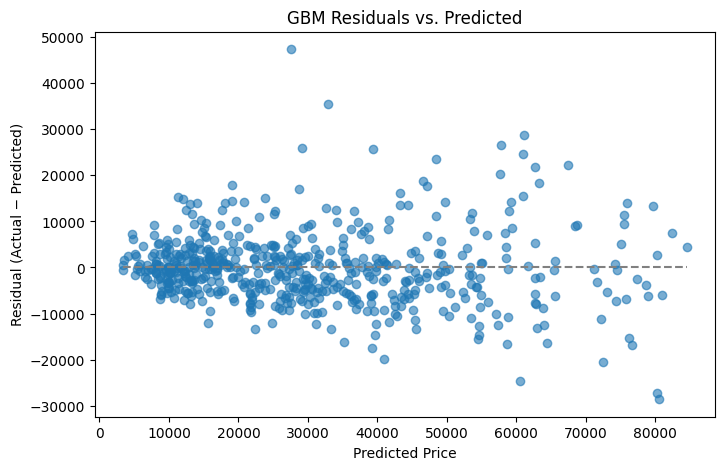

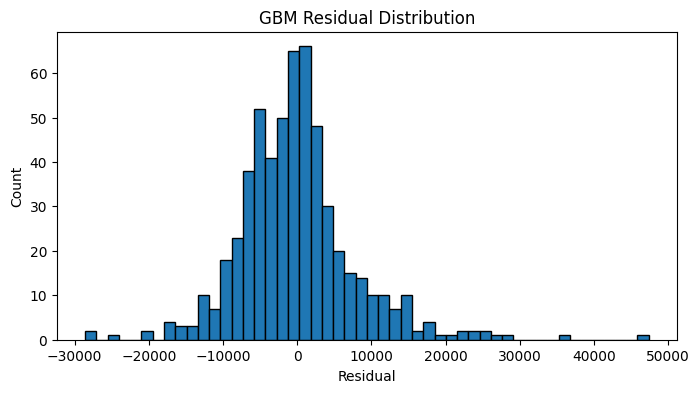

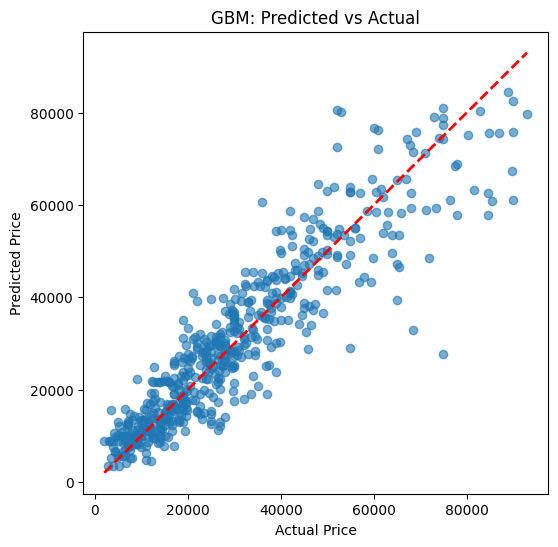

In [176]:
best_gbm = gs_gbm.best_estimator_
y_pred = best_gbm.predict(X_test)
residuals = y_test - y_pred

# Residuals vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.hlines(0, y_pred.min(), y_pred.max(), linestyles='dashed', colors='gray')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual − Predicted)')
plt.title('GBM Residuals vs. Predicted')
plt.show()

# Residual Histogram
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('GBM Residual Distribution')
plt.show()

# Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('GBM: Predicted vs Actual')
plt.show()


Which features have the most significant impact on predicting car prices in the tuned Random Forest model?

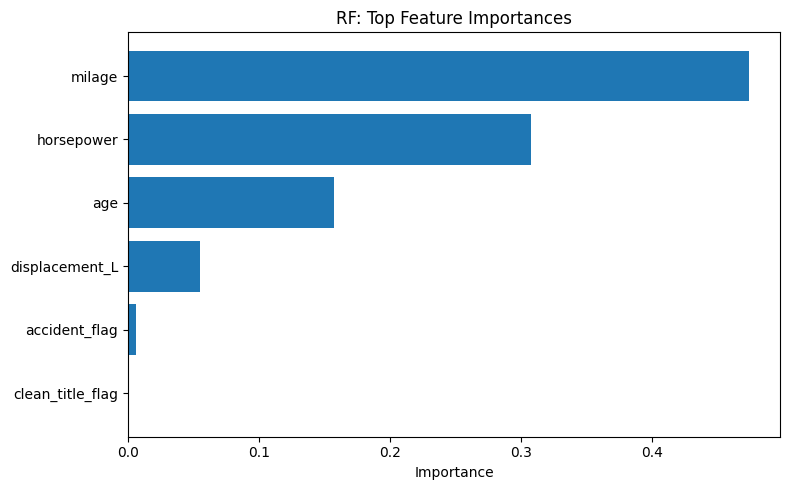

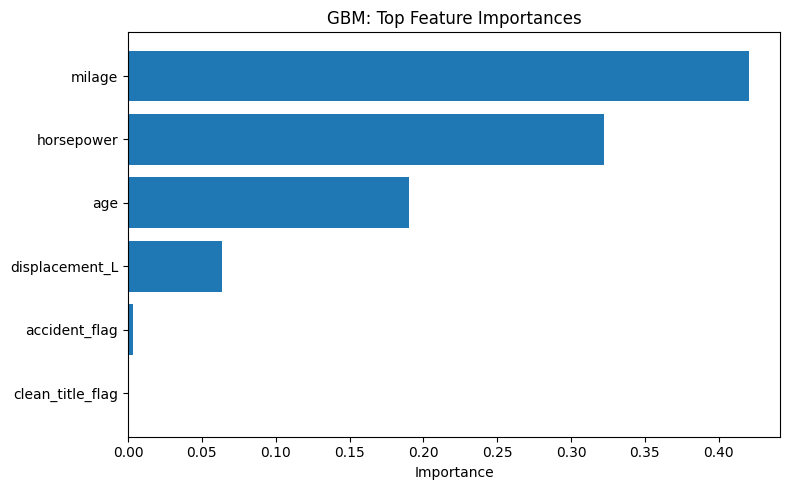

In [177]:
def plot_top_importances(model, feature_names, top_n=10, title="Feature Importances"):
    importances = model.feature_importances_
    n_features = len(feature_names)
    top_n = min(top_n, n_features)
    idx = np.argsort(importances)[::-1][:top_n]
    plt.figure(figsize=(8, 5))
    plt.barh(range(top_n)[::-1], importances[idx], align='center')
    plt.yticks(range(top_n)[::-1], [feature_names[i] for i in idx])
    plt.xlabel('Importance')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Assume X_train is a DataFrame:
features = X_train.columns.tolist()

plot_top_importances(gs_rf.best_estimator_, features, title="RF: Top Feature Importances")
plot_top_importances(gs_gbm.best_estimator_, features, title="GBM: Top Feature Importances")



| Model          | CV R² (Train) | CV RMSE | Test R²   | Test MSE      | RMSE (from MSE) |
| -------------- | ------------- | ------- | --------- | ------------- | --------------- |
| Random Forest  | **0.975**     | 8750.35 | **0.788** | 81,599,371.39 | ≈ 9,036         |
| Gradient Boost | **0.972**     | 8110.65 | **0.841** | 61,240,768.53 | ≈ 7,825         |

✅ Gradient Boosting (Best Model)
Cross-Validation (CV):

RMSE: 8,110

R² (train): 0.972

Test Set:

MSE: 61,240,768 → RMSE ≈ 7,824

R² (test): 0.841

➤ Interpretation:
Explains 84.1% of variance in car prices on unseen data — that's very strong for real-world regression.

Very low error: An average price prediction error of ~$7.8k is quite good for a use case like car pricing.

Good generalization: CV and test RMSE are close, meaning no significant overfitting.



On average, RF predictions miss the true sale price by about $9 k, while GBM is tighter at about $7.8 k.

| Model                 | CV RMSE | Test RMSE (from true split) | Difference | Notes                                                                 |
| --------------------- | ------- | --------------------------- | ---------- | --------------------------------------------------------------------- |
| **Random Forest**     | 8,750   | 8,999                       | +249       | CV slightly underestimates error but very close → good generalization |
| **Gradient Boosting** | 8,110   | 8,795                       | +685       | Slight gap, but still tight → strong generalization                   |


## SAVE THE MODEL

In [178]:
import joblib

# Save the best Gradient Boosting model to disk
joblib.dump(gs_gbm.best_estimator_, "best_gradient_boosting_model.joblib")



['best_gradient_boosting_model.joblib']

In [179]:
# To load later:
loaded_model = joblib.load("best_gradient_boosting_model.joblib")